Quantas frases falam sobre amor?
regressão logistica com penalização
Arvore com parametro oob = false
Tentar excluir colunas que as palavras aparecem pouco

In [31]:
import pandas as pd
import ast

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf.copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "love" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())

tag_love
0    85
1    15
Name: count, dtype: int64


In [11]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

In [12]:
#modelo = LogisticRegression(
#    max_iter=1000,
#    class_weight="balanced",
#    penalty="l1",
#    solver = "liblinear"
#)

In [57]:

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [61]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= 0.39).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.82      0.86        85
           1       0.35      0.53      0.42        15

    accuracy                           0.78       100
   macro avg       0.63      0.68      0.64       100
weighted avg       0.82      0.78      0.80       100



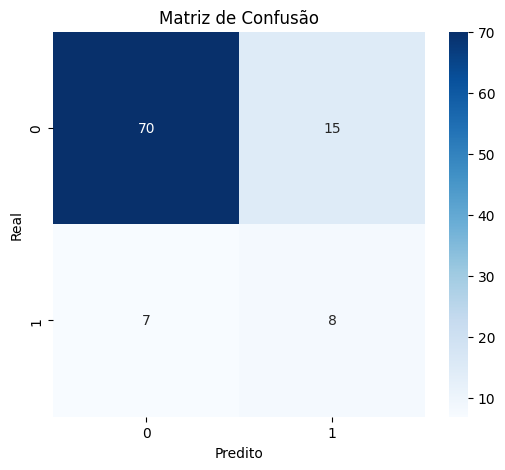

In [62]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [49]:
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_love": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_love",
    ascending=False
).head(20)

,frase,tags,real,probabilidade_love,predicao
22,"“If you judge people, you have no time to love...",['attributed-no-source'],0,0.558813,1
49,“Love does not begin and end the way we seem t...,['love'],1,0.520804,1
20,"“I love you without knowing how, or when, or f...","['love', 'poetry']",1,0.495137,1
81,“A lady's imagination is very rapid; it jumps ...,"['humor', 'love', 'romantic', 'women']",1,0.467096,1
35,“All you need is love. But a little chocolate ...,"['chocolate', 'food', 'humor']",0,0.464742,1
23,“Anyone who thinks sitting in church can make ...,"['humor', 'religion']",0,0.451171,1
91,“I'm the one that's got to die when it's time ...,"['death', 'life']",0,0.449274,1
17,"“It is not a lack of love, but a lack of frien...","['friendship', 'lack-of-friendship', 'lack-of-...",1,0.442851,1
43,"“If you can make a woman laugh, you can make h...","['girls', 'love']",1,0.435777,1
24,“Beauty is in the eye of the beholder and it m...,['humor'],0,0.423471,1
